## 0. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import defaultdict

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

import os
os.makedirs('outputs', exist_ok=True)

RISK_COLORS = {'Low':'#2ecc71','Moderate':'#f39c12','High':'#e67e22','Very High':'#e74c3c'}
CLUSTER_COLORS = ['#3498db','#9b59b6','#1abc9c','#e74c3c']
ORDER = ['Low','Moderate','High','Very High']
sns.set_theme(style='whitegrid', font_scale=1.1)

print("All libraries loaded successfully.")


All libraries loaded successfully.


---
## Step 1: Data Loading & Preprocessing


In [2]:
df = pd.read_csv('data/health_risk_assessment.csv')
print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Dataset loaded: 1000 rows x 19 columns


,PatientID,AssessmentDate,Age,Gender,BMI,SmokingStatus,AlcoholConsumption,ExerciseFrequency,DietQuality,SleepQuality,StressLevel,SystolicBP,DiastolicBP,Cholesterol,BloodSugar,ExistingCondition,FamilyHistory,RiskScore,RiskCategory
0,PAT00328,2021-04-01,21,Female,28.5,Former,Light,Rare,Poor,Poor,Very High,94,61,173,125,Diabetes,Yes,10,High
1,PAT00288,2022-03-25,71,Male,25.3,Current - Heavy,Moderate,NaN,Fair,Excellent,High,125,69,205,156,NaN,Yes,13,Very High
2,PAT00195,2021-01-31,63,Female,29.2,Current - Light,NaN,Regular,Poor,Excellent,Low,160,78,242,119,Arthritis,Yes,14,Very High
3,PAT00024,2022-07-22,55,Male,33.6,Former,NaN,Regular,Good,Excellent,High,110,83,240,123,Arthritis,No,7,Moderate
4,PAT00360,2020-10-19,39,Male,24.8,Former,Heavy,Regular,Good,Fair,High,97,74,158,150,Heart Disease,No,6,Moderate


### 1.1 Missing Value Analysis

Missing values per column:
AlcoholConsumption    226
ExerciseFrequency     201
ExistingCondition     165
dtype: int64


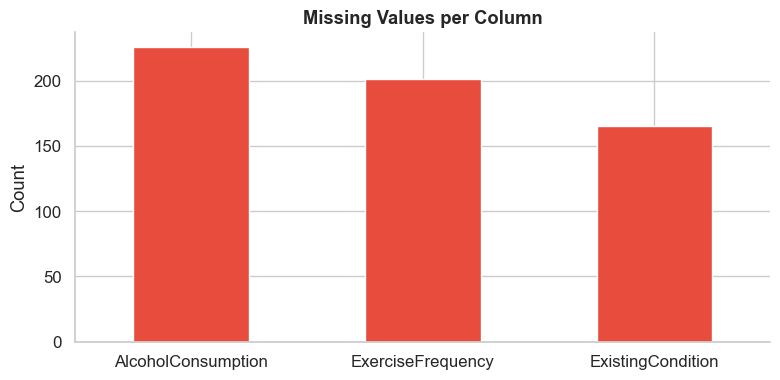

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values per column:")
print(missing)

fig, ax = plt.subplots(figsize=(8,4))
missing.plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='white')
ax.set_title('Missing Values per Column', fontweight='bold')
ax.set_ylabel('Count'); ax.tick_params(axis='x', rotation=0)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('outputs/00_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.2 Handling Missing Values

In [4]:
df_clean = df.copy()
df_clean['AlcoholConsumption'] = df_clean['AlcoholConsumption'].fillna(df_clean['AlcoholConsumption'].mode()[0])
df_clean['ExerciseFrequency']  = df_clean['ExerciseFrequency'].fillna(df_clean['ExerciseFrequency'].mode()[0])
df_clean['ExistingCondition']  = df_clean['ExistingCondition'].fillna('None')

print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")
print()
print("RiskCategory distribution:")
print(df_clean['RiskCategory'].value_counts())


Missing values after cleaning: 0

RiskCategory distribution:
RiskCategory
High         594
Very High    241
Moderate     157
Low            8
Name: count, dtype: int64


### 1.3 Feature Engineering

In [5]:
df_clean['BP_Category']  = np.where((df_clean['SystolicBP']>140)|(df_clean['DiastolicBP']>90),'High_BP','Normal_BP')
df_clean['Chol_Category']= pd.cut(df_clean['Cholesterol'], bins=[0,200,240,400], labels=['Desirable','Borderline','High'])
df_clean['BMI_Category'] = pd.cut(df_clean['BMI'], bins=[0,18.5,25,30,50], labels=['Underweight','Normal','Overweight','Obese'])
df_clean['AgeGroup']     = pd.cut(df_clean['Age'], bins=[0,40,55,70,100], labels=['Young','MiddleAge','Senior','Elderly'])
df_clean['Sugar_Category']= pd.cut(df_clean['BloodSugar'], bins=[0,100,126,300], labels=['Normal','Prediabetic','Diabetic'])

print("Feature engineering complete.")
df_clean[['AgeGroup','BMI_Category','BP_Category','Chol_Category','Sugar_Category']].head()


Feature engineering complete.


,AgeGroup,BMI_Category,BP_Category,Chol_Category,Sugar_Category
0,Young,Overweight,Normal_BP,Desirable,Prediabetic
1,Elderly,Overweight,Normal_BP,Borderline,Diabetic
2,Senior,Overweight,High_BP,High,Prediabetic
3,MiddleAge,Obese,Normal_BP,Borderline,Prediabetic
4,Young,Normal,Normal_BP,Desirable,Diabetic


### 1.4 Encode Features

In [6]:
ORDINAL_MAPS = {
    'SmokingStatus':     {'Never':0,'Former':1,'Current - Light':2,'Current - Heavy':3},
    'AlcoholConsumption':{'Light':0,'Moderate':1,'Heavy':2},
    'ExerciseFrequency': {'Rare':0,'Moderate':1,'Regular':2,'Intensive':3},
    'DietQuality':       {'Poor':0,'Fair':1,'Good':2,'Excellent':3},
    'SleepQuality':      {'Poor':0,'Fair':1,'Good':2,'Excellent':3},
    'StressLevel':       {'Low':0,'Moderate':1,'High':2,'Very High':3},
    'Gender':            {'Male':0,'Female':1},
    'FamilyHistory':     {'No':0,'Yes':1},
    'BP_Category':       {'Normal_BP':0,'High_BP':1},
}
FEATURE_COLS = ['Age','BMI','SmokingStatus','AlcoholConsumption','ExerciseFrequency',
                'DietQuality','SleepQuality','StressLevel','SystolicBP','DiastolicBP',
                'Cholesterol','BloodSugar','ExistingCondition','FamilyHistory','Gender']

df_enc = df_clean.copy()
for col, mapping in ORDINAL_MAPS.items():
    df_enc[col] = df_enc[col].map(mapping)

le = LabelEncoder()
df_enc['ExistingCondition'] = le.fit_transform(df_enc['ExistingCondition'])
df_enc['RiskCategory_num']  = df_enc['RiskCategory'].map({'Low':0,'Moderate':1,'High':2,'Very High':3})

X = df_enc[FEATURE_COLS].values.astype(float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix ready: {X_scaled.shape}")


Feature matrix ready: (1000, 15)


---
## Step 2: Exploratory Data Analysis

### 2.1 Risk Category Distribution

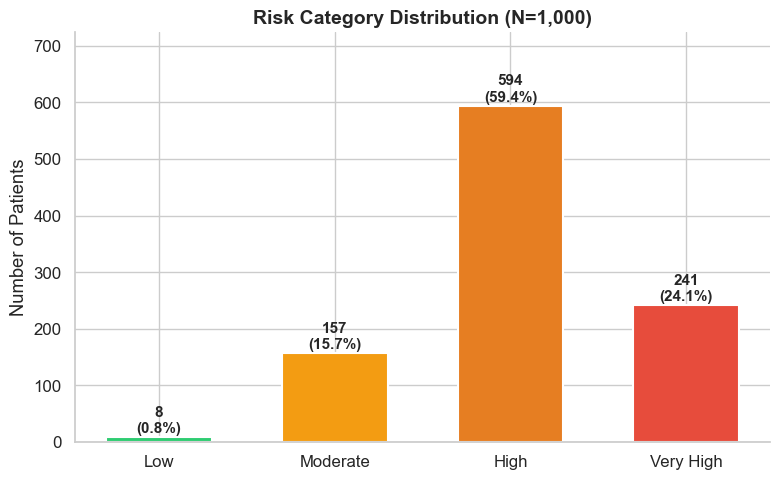

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
counts = df_clean['RiskCategory'].value_counts().reindex(ORDER)
bars = ax.bar(ORDER, counts, color=[RISK_COLORS[r] for r in ORDER], edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
            f'{val}\n({val/len(df_clean)*100:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Risk Category Distribution (N=1,000)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Patients'); ax.set_ylim(0, max(counts)*1.22)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('outputs/01_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.2 Age Distribution by Risk Category

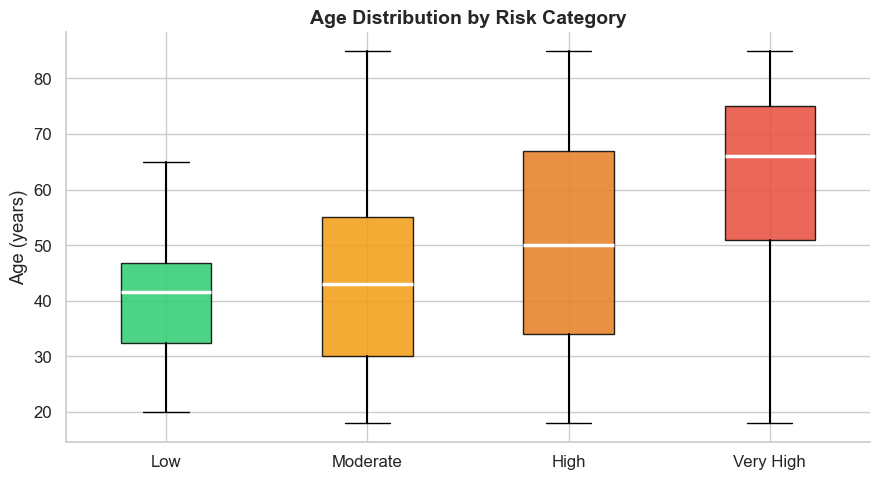

Clinical means by risk category:


,Age,BMI,SystolicBP,Cholesterol,BloodSugar
RiskCategory,,,,,
High,50.3,26.0,136.1,224.3,135.5
Low,41.1,20.4,126.9,201.8,109.6
Moderate,45.2,24.4,122.1,204.9,115.0
Very High,61.5,27.8,143.9,242.8,151.7


In [8]:
fig, ax = plt.subplots(figsize=(9,5))
data = [df_clean[df_clean['RiskCategory']==r]['Age'].values for r in ORDER]
bp = ax.boxplot(data, patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(linewidth=1.5), flierprops=dict(marker='o', markersize=4, alpha=0.4))
for patch, r in zip(bp['boxes'], ORDER):
    patch.set_facecolor(RISK_COLORS[r]); patch.set_alpha(0.85)
ax.set_xticklabels(ORDER)
ax.set_title('Age Distribution by Risk Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Age (years)'); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('outputs/02_age_by_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print("Clinical means by risk category:")
df_clean.groupby('RiskCategory')[['Age','BMI','SystolicBP','Cholesterol','BloodSugar']].mean().round(1)


### 2.3 Correlation Heatmap

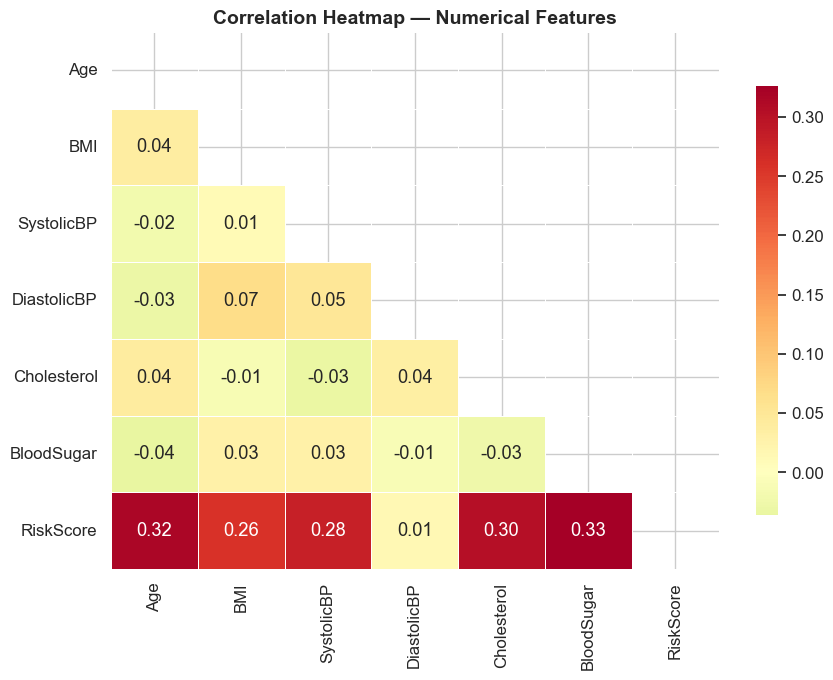

In [9]:
fig, ax = plt.subplots(figsize=(9,7))
num_cols = ['Age','BMI','SystolicBP','DiastolicBP','Cholesterol','BloodSugar','RiskScore']
corr = df_clean[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink':0.8})
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.4 Lifestyle Factors vs Risk

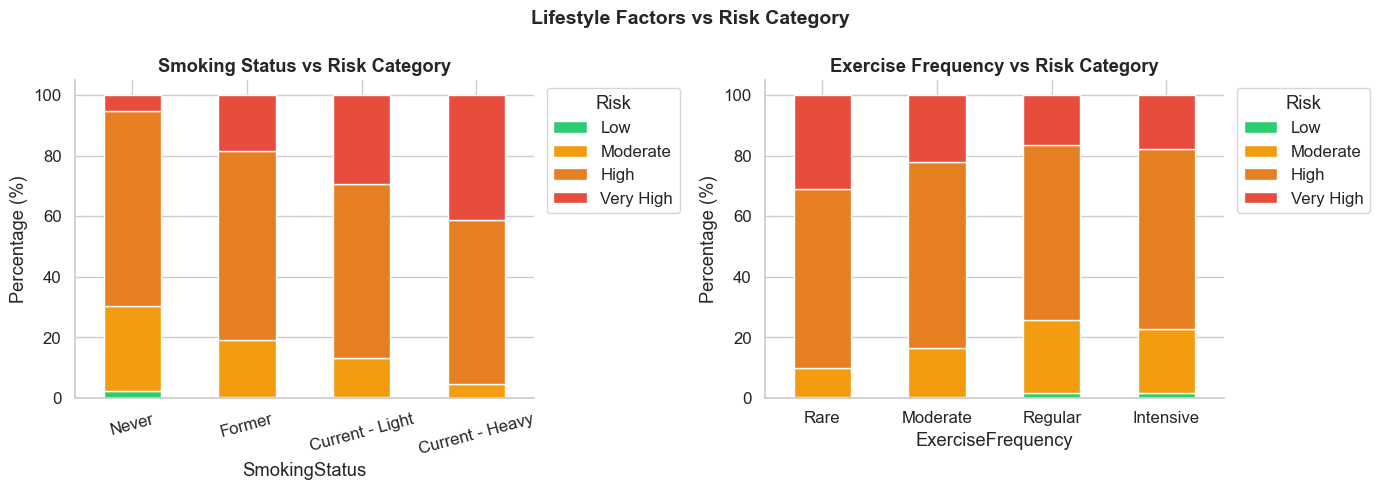

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sm_order = ['Never','Former','Current - Light','Current - Heavy']
sm = pd.crosstab(df_clean['SmokingStatus'], df_clean['RiskCategory']).reindex(sm_order)
(sm.div(sm.sum(axis=1), axis=0)*100)[ORDER].plot(kind='bar', stacked=True, ax=axes[0],
    color=[RISK_COLORS[r] for r in ORDER], edgecolor='white')
axes[0].set_title('Smoking Status vs Risk Category', fontweight='bold')
axes[0].set_ylabel('Percentage (%)'); axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Risk', bbox_to_anchor=(1.01,1)); axes[0].spines[['top','right']].set_visible(False)

ex_order = ['Rare','Moderate','Regular','Intensive']
ex = pd.crosstab(df_clean['ExerciseFrequency'], df_clean['RiskCategory']).reindex(ex_order)
(ex.div(ex.sum(axis=1), axis=0)*100)[ORDER].plot(kind='bar', stacked=True, ax=axes[1],
    color=[RISK_COLORS[r] for r in ORDER], edgecolor='white')
axes[1].set_title('Exercise Frequency vs Risk Category', fontweight='bold')
axes[1].set_ylabel('Percentage (%)'); axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Risk', bbox_to_anchor=(1.01,1)); axes[1].spines[['top','right']].set_visible(False)
plt.suptitle('Lifestyle Factors vs Risk Category', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs/04_lifestyle_vs_risk.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Step 3: K-Means Clustering

Discovering natural patient groupings **without using the RiskCategory label**.

### 3.1 Optimal k — Elbow & Silhouette

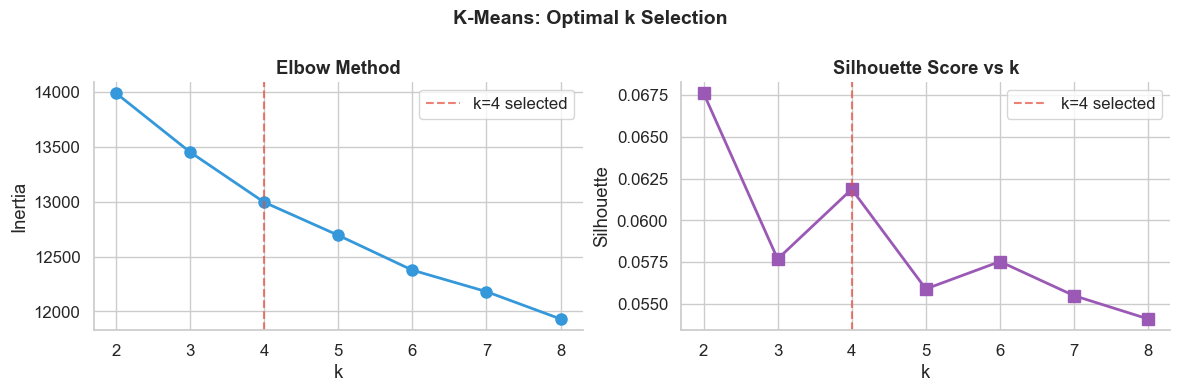

Silhouette scores (k=2..8): [0.068, 0.058, 0.062, 0.056, 0.058, 0.055, 0.054]


In [11]:
inertias, silhouettes = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(range(2,9), inertias, 'o-', color='#3498db', linewidth=2, markersize=8)
axes[0].axvline(4, color='#e74c3c', linestyle='--', alpha=0.7, label='k=4 selected')
axes[0].set_title('Elbow Method', fontweight='bold'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)
axes[1].plot(range(2,9), silhouettes, 's-', color='#9b59b6', linewidth=2, markersize=8)
axes[1].axvline(4, color='#e74c3c', linestyle='--', alpha=0.7, label='k=4 selected')
axes[1].set_title('Silhouette Score vs k', fontweight='bold'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)
plt.suptitle('K-Means: Optimal k Selection', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs/05_kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Silhouette scores (k=2..8): {[round(s,3) for s in silhouettes]}")


### 3.2 Final Clustering & PCA Projection

Silhouette score (k=4): 0.062


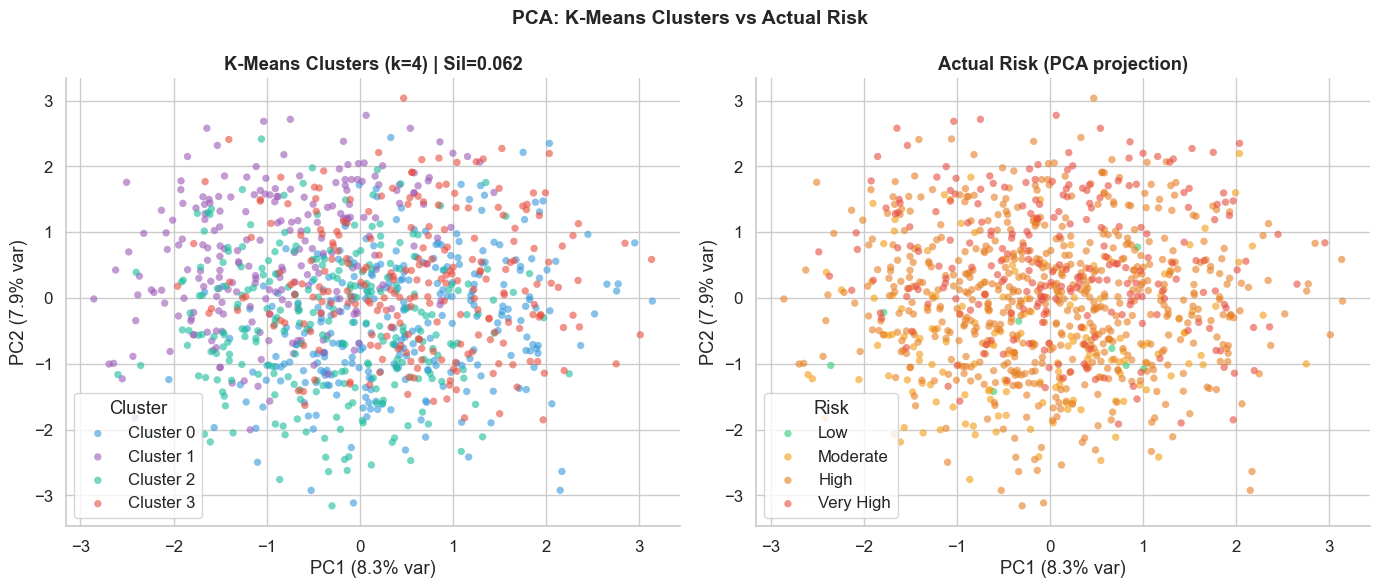

In [12]:
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = km4.fit_predict(X_scaled)
sil_final = silhouette_score(X_scaled, cluster_labels)
df_clean['Cluster'] = cluster_labels
print(f"Silhouette score (k=4): {sil_final:.3f}")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
pca_var = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14,6))
for c in range(4):
    mask = cluster_labels==c
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], c=CLUSTER_COLORS[c],
                    label=f'Cluster {c}', alpha=0.6, s=28, edgecolors='none')
axes[0].set_title(f'K-Means Clusters (k=4) | Sil={sil_final:.3f}', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_var[0]*100:.1f}% var)'); axes[0].set_ylabel(f'PC2 ({pca_var[1]*100:.1f}% var)')
axes[0].legend(title='Cluster'); axes[0].spines[['top','right']].set_visible(False)
for r in ORDER:
    mask = df_clean['RiskCategory']==r
    axes[1].scatter(X_pca[mask,0], X_pca[mask,1], c=RISK_COLORS[r], label=r, alpha=0.6, s=28, edgecolors='none')
axes[1].set_title('Actual Risk (PCA projection)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_var[0]*100:.1f}% var)'); axes[1].set_ylabel(f'PC2 ({pca_var[1]*100:.1f}% var)')
axes[1].legend(title='Risk'); axes[1].spines[['top','right']].set_visible(False)
plt.suptitle('PCA: K-Means Clusters vs Actual Risk', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs/06_kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Cluster Profiles & Risk Composition

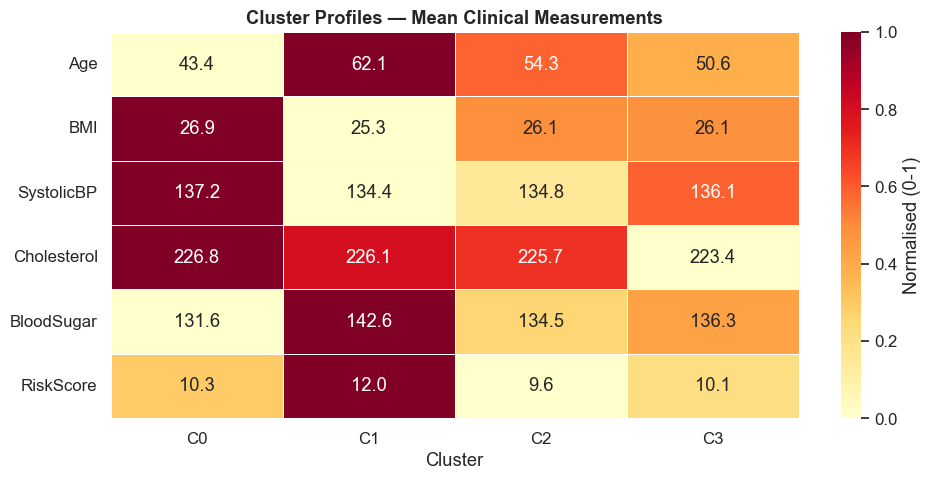

Cluster → Risk composition (%):


RiskCategory,Low,Moderate,High,Very High
Cluster,,,,
0,0.4,15.8,62.7,21.1
1,0.4,4.9,53.5,41.2
2,0.8,22.9,61.3,15.0
3,1.7,18.2,59.1,21.1


In [13]:
profile_cols = ['Age','BMI','SystolicBP','Cholesterol','BloodSugar','RiskScore']
cp = df_clean.groupby('Cluster')[profile_cols].mean()
cp_norm = (cp - cp.min()) / (cp.max() - cp.min())

fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(cp_norm.T, annot=cp.T.round(1), fmt='.1f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, cbar_kws={'label':'Normalised (0-1)'})
ax.set_title('Cluster Profiles — Mean Clinical Measurements', fontweight='bold')
ax.set_xticklabels([f'C{i}' for i in range(4)])
plt.tight_layout(); plt.savefig('outputs/07_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

risk_comp = pd.crosstab(df_clean['Cluster'], df_clean['RiskCategory'], normalize='index')*100
print("Cluster → Risk composition (%):")
display(risk_comp[ORDER].round(1))


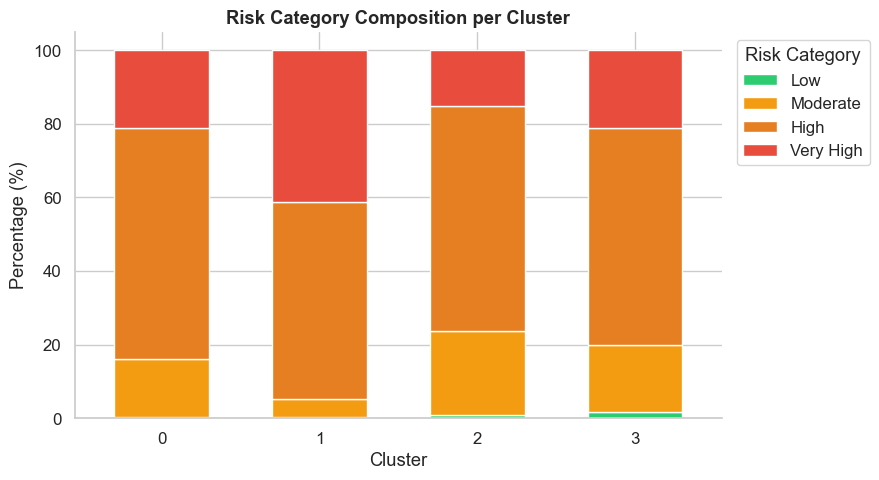

In [14]:
fig, ax = plt.subplots(figsize=(9,5))
risk_comp[ORDER].plot(kind='bar', stacked=True, ax=ax,
    color=[RISK_COLORS[r] for r in ORDER], edgecolor='white', width=0.6)
ax.set_title('Risk Category Composition per Cluster', fontweight='bold')
ax.set_xlabel('Cluster'); ax.set_ylabel('Percentage (%)')
ax.tick_params(axis='x', rotation=0); ax.legend(title='Risk Category', bbox_to_anchor=(1.01,1))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('outputs/08_cluster_risk_composition.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Step 4: Association Rule Mining

Mining frequent co-occurring risk factor combinations from the real patient data
using a custom Apriori implementation — no external libraries needed.


In [15]:
# Discretise for mining
df_mine = df_clean.copy()
df_mine['AgeGroup']  = pd.cut(df_mine['Age'], bins=[0,40,55,70,100], labels=['Young','MiddleAge','Senior','Elderly'])
df_mine['BMI_Cat']   = pd.cut(df_mine['BMI'], bins=[0,18.5,25,30,50], labels=['Underweight','Normal','Overweight','Obese'])
df_mine['SBP_Cat']   = pd.cut(df_mine['SystolicBP'], bins=[0,130,160,200], labels=['Normal_BP','Elevated_BP','High_BP'])
df_mine['Chol_Cat']  = pd.cut(df_mine['Cholesterol'], bins=[0,200,240,400], labels=['Desirable_Chol','Borderline_Chol','High_Chol'])
df_mine['Sugar_Cat'] = pd.cut(df_mine['BloodSugar'], bins=[0,100,126,300], labels=['Normal_Sugar','Prediabetic','Diabetic_Sugar'])

ITEM_COLS = ['AgeGroup','BMI_Cat','SBP_Cat','Chol_Cat','Sugar_Cat',
             'SmokingStatus','AlcoholConsumption','ExerciseFrequency',
             'DietQuality','SleepQuality','StressLevel',
             'ExistingCondition','FamilyHistory','RiskCategory']

records = []
for _, row in df_mine[ITEM_COLS].iterrows():
    records.append([f"{col}={str(row[col])}" for col in ITEM_COLS])

n_rec = len(records)
MIN_SUP, MIN_CONF, MIN_LIFT = 0.05, 0.55, 1.2

# Count 1-itemsets
single_counts = defaultdict(int)
for rec in records:
    for item in rec: single_counts[item] += 1
freq1 = {item: cnt/n_rec for item, cnt in single_counts.items() if cnt/n_rec >= MIN_SUP}
print(f"Frequent 1-itemsets: {len(freq1)}")

# Count 2-itemsets
pair_counts = defaultdict(int)
for rec in records:
    fi = sorted([i for i in rec if i in freq1])
    for a, b in combinations(fi, 2): pair_counts[(a,b)] += 1

# Generate rules from pairs
rules = []
for (a,b), cnt in pair_counts.items():
    sup = cnt/n_rec
    if sup < MIN_SUP: continue
    for ant, cons in [(a,b),(b,a)]:
        if 'RiskCategory' in cons:
            conf = sup / freq1[ant]
            lift = conf / freq1[cons]
            if conf >= MIN_CONF and lift >= MIN_LIFT:
                rules.append({'antecedent':ant,'consequent':cons,
                              'support':round(sup,3),'confidence':round(conf,3),'lift':round(lift,3)})

# Count 3-itemsets and generate triple rules
triple_counts = defaultdict(int)
for rec in records:
    fi = sorted([i for i in rec if i in freq1])
    for t in combinations(fi, 3): triple_counts[t] += 1

for triple, cnt in triple_counts.items():
    sup = cnt/n_rec
    if sup < MIN_SUP: continue
    for i in range(3):
        cons = triple[i]
        if 'RiskCategory' not in cons: continue
        ant_pair = tuple(x for j,x in enumerate(triple) if j!=i)
        ap_cnt = pair_counts.get(ant_pair, pair_counts.get((ant_pair[1],ant_pair[0]), 0))
        if ap_cnt == 0: continue
        conf = sup / (ap_cnt/n_rec)
        lift = conf / freq1[cons]
        if conf >= MIN_CONF and lift >= MIN_LIFT:
            rules.append({'antecedent':' + '.join(ant_pair),'consequent':cons,
                          'support':round(sup,3),'confidence':round(conf,3),'lift':round(lift,3)})

rules_df = pd.DataFrame(rules).sort_values('lift', ascending=False).drop_duplicates().reset_index(drop=True)
print(f"Risk-targeting rules discovered: {len(rules_df)}")
print()
print("Top 10 rules:")
display(rules_df.head(10))


Frequent 1-itemsets: 51
Risk-targeting rules discovered: 19

Top 10 rules:


,antecedent,consequent,support,confidence,lift
0,Chol_Cat=High_Chol + SmokingStatus=Current - H...,RiskCategory=Very High,0.063,0.600,2.490
1,AgeGroup=Elderly + Chol_Cat=High_Chol,RiskCategory=Very High,0.059,0.584,2.424
2,Chol_Cat=High_Chol + DietQuality=Poor,RiskCategory=Very High,0.067,0.583,2.417
3,AgeGroup=Elderly + Sugar_Cat=Diabetic_Sugar,RiskCategory=Very High,0.075,0.573,2.376
4,SBP_Cat=High_BP + SmokingStatus=Never,RiskCategory=High,0.051,0.864,1.455
5,SmokingStatus=Never + StressLevel=Very High,RiskCategory=High,0.057,0.814,1.371
6,AgeGroup=Young + SBP_Cat=High_BP,RiskCategory=High,0.063,0.808,1.360
7,SmokingStatus=Never + Sugar_Cat=Diabetic_Sugar,RiskCategory=High,0.097,0.752,1.266
8,AgeGroup=Young + DietQuality=Fair,RiskCategory=High,0.066,0.750,1.263
9,AgeGroup=Young + SleepQuality=Good,RiskCategory=High,0.050,0.746,1.256


### 4.1 Top Rules by Lift

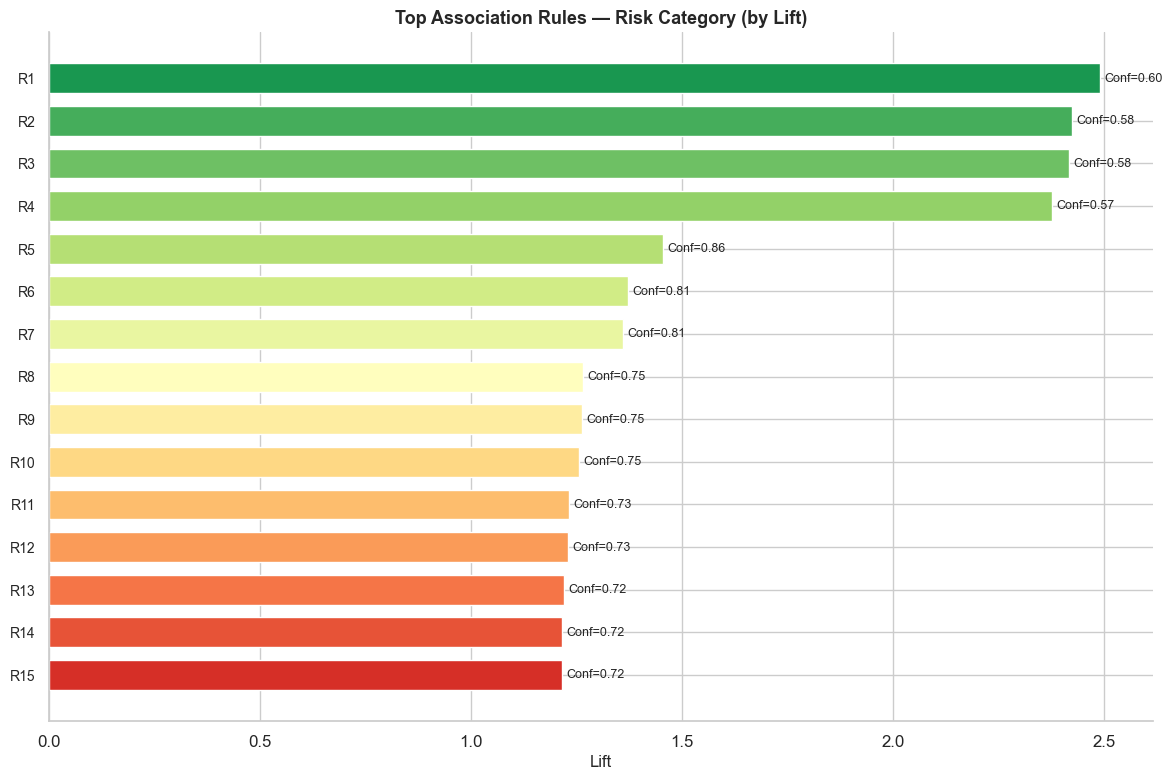

Rule legend:
R1: Chol_Cat=High_Chol + SmokingStatus=Current - Heavy → RiskCategory=Very High
     sup=0.063 | conf=0.600 | lift=2.490
R2: AgeGroup=Elderly + Chol_Cat=High_Chol → RiskCategory=Very High
     sup=0.059 | conf=0.584 | lift=2.424
R3: Chol_Cat=High_Chol + DietQuality=Poor → RiskCategory=Very High
     sup=0.067 | conf=0.583 | lift=2.417
R4: AgeGroup=Elderly + Sugar_Cat=Diabetic_Sugar → RiskCategory=Very High
     sup=0.075 | conf=0.573 | lift=2.376
R5: SBP_Cat=High_BP + SmokingStatus=Never → RiskCategory=High
     sup=0.051 | conf=0.864 | lift=1.455
R6: SmokingStatus=Never + StressLevel=Very High → RiskCategory=High
     sup=0.057 | conf=0.814 | lift=1.371
R7: AgeGroup=Young + SBP_Cat=High_BP → RiskCategory=High
     sup=0.063 | conf=0.808 | lift=1.360
R8: SmokingStatus=Never + Sugar_Cat=Diabetic_Sugar → RiskCategory=High
     sup=0.097 | conf=0.752 | lift=1.266
R9: AgeGroup=Young + DietQuality=Fair → RiskCategory=High
     sup=0.066 | conf=0.750 | lift=1.263
R10: AgeGroup=Y

In [16]:
top15 = rules_df.head(min(15, len(rules_df))).copy()

fig, ax = plt.subplots(figsize=(12,8))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top15)))
bars = ax.barh(range(len(top15)), top15['lift'], color=colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([f'R{i+1}' for i in range(len(top15))], fontsize=10)
ax.set_xlabel('Lift', fontsize=12)
ax.set_title('Top Association Rules — Risk Category (by Lift)', fontweight='bold', fontsize=13)
for bar, row in zip(bars, top15.itertuples()):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f'Conf={row.confidence:.2f}', va='center', fontsize=9)
ax.spines[['top','right']].set_visible(False); ax.invert_yaxis()
plt.tight_layout(); plt.savefig('outputs/09_association_rules_lift.png', dpi=150, bbox_inches='tight')
plt.show()

print("Rule legend:")
for i, (_, row) in enumerate(top15.iterrows()):
    print(f"R{i+1}: {row['antecedent']} → {row['consequent']}")
    print(f"     sup={row['support']:.3f} | conf={row['confidence']:.3f} | lift={row['lift']:.3f}")


### 4.2 Support vs Confidence Scatter

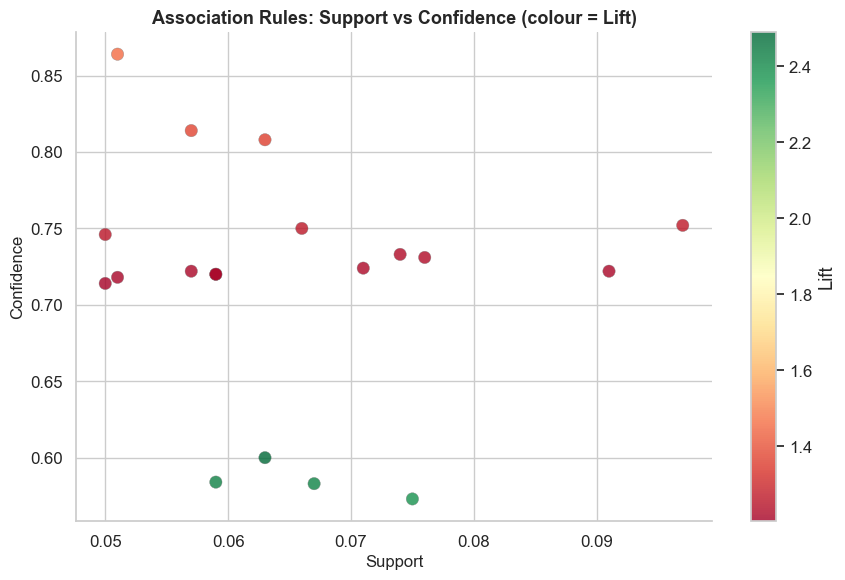

All 19 rules saved to outputs/association_rules.csv


In [17]:
fig, ax = plt.subplots(figsize=(9,6))
sc = ax.scatter(rules_df['support'], rules_df['confidence'],
                c=rules_df['lift'], cmap='RdYlGn', s=80, alpha=0.8,
                edgecolors='grey', linewidth=0.3)
plt.colorbar(sc, ax=ax, label='Lift')
ax.set_xlabel('Support', fontsize=12); ax.set_ylabel('Confidence', fontsize=12)
ax.set_title('Association Rules: Support vs Confidence (colour = Lift)',
             fontweight='bold', fontsize=13)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('outputs/10_rules_support_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

rules_df.to_csv('outputs/association_rules.csv', index=False)
print(f"All {len(rules_df)} rules saved to outputs/association_rules.csv")


---
## Step 5: Anomaly Detection

Identifying unusual patient profiles using Isolation Forest and Local Outlier Factor.

In [18]:
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso_labels = iso.fit_predict(X_scaled)
iso_scores = iso.decision_function(X_scaled)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X_scaled)
lof_scores = -lof.negative_outlier_factor_

df_clean['iso_label'] = iso_labels
df_clean['lof_label'] = lof_labels
df_clean['is_anomaly'] = ((iso_labels==-1) & (lof_labels==-1)).astype(int)

n_iso = (iso_labels==-1).sum()
n_lof = (lof_labels==-1).sum()
n_con = df_clean['is_anomaly'].sum()
print(f"Isolation Forest anomalies : {n_iso} ({n_iso/len(df_clean)*100:.1f}%)")
print(f"LOF anomalies              : {n_lof} ({n_lof/len(df_clean)*100:.1f}%)")
print(f"Consensus anomalies        : {n_con}")


Isolation Forest anomalies : 50 (5.0%)
LOF anomalies              : 50 (5.0%)
Consensus anomalies        : 25


### 5.1 PCA Projection with Anomalies

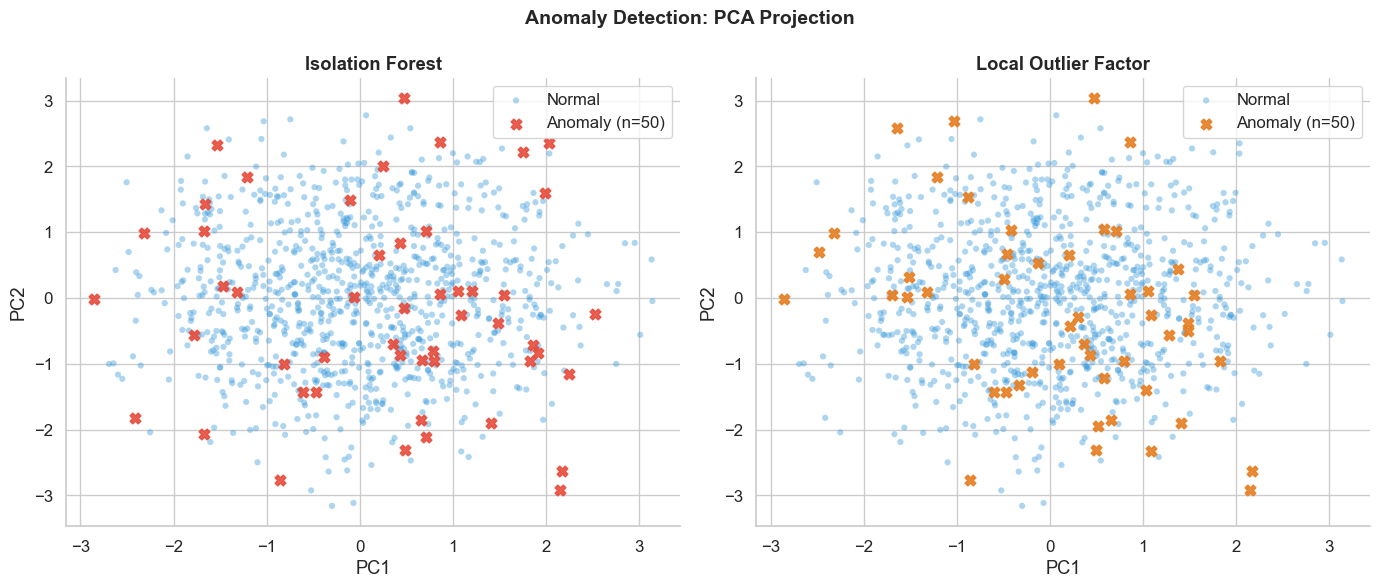

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].scatter(X_pca[iso_labels==1,0], X_pca[iso_labels==1,1],
                c='#3498db', alpha=0.4, s=20, label='Normal', edgecolors='none')
axes[0].scatter(X_pca[iso_labels==-1,0], X_pca[iso_labels==-1,1],
                c='#e74c3c', alpha=0.9, s=60, marker='X', label=f'Anomaly (n={n_iso})', zorder=5)
axes[0].set_title('Isolation Forest', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

axes[1].scatter(X_pca[lof_labels==1,0], X_pca[lof_labels==1,1],
                c='#3498db', alpha=0.4, s=20, label='Normal', edgecolors='none')
axes[1].scatter(X_pca[lof_labels==-1,0], X_pca[lof_labels==-1,1],
                c='#e67e22', alpha=0.9, s=60, marker='X', label=f'Anomaly (n={n_lof})', zorder=5)
axes[1].set_title('Local Outlier Factor', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)
plt.suptitle('Anomaly Detection: PCA Projection', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs/11_anomaly_pca.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 Score Distributions & Anomaly Rate by Risk

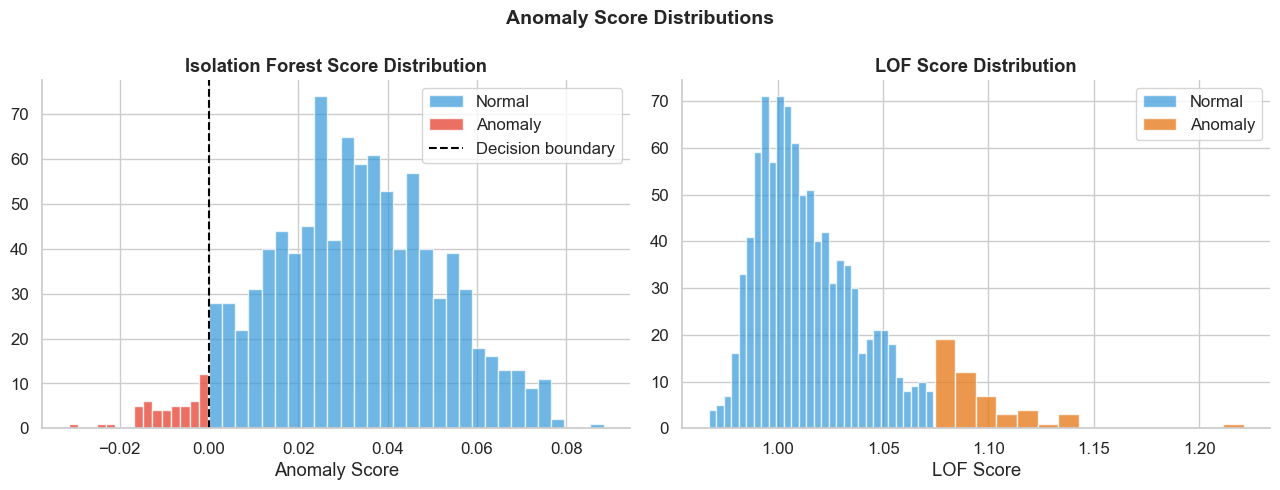

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].hist(iso_scores[iso_labels==1], bins=30, alpha=0.7, color='#3498db', label='Normal')
axes[0].hist(iso_scores[iso_labels==-1], bins=15, alpha=0.8, color='#e74c3c', label='Anomaly')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.5, label='Decision boundary')
axes[0].set_title('Isolation Forest Score Distribution', fontweight='bold')
axes[0].set_xlabel('Anomaly Score'); axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)
axes[1].hist(lof_scores[lof_labels==1], bins=30, alpha=0.7, color='#3498db', label='Normal')
axes[1].hist(lof_scores[lof_labels==-1], bins=15, alpha=0.8, color='#e67e22', label='Anomaly')
axes[1].set_title('LOF Score Distribution', fontweight='bold')
axes[1].set_xlabel('LOF Score'); axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)
plt.suptitle('Anomaly Score Distributions', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs/12_anomaly_scores.png', dpi=150, bbox_inches='tight')
plt.show()


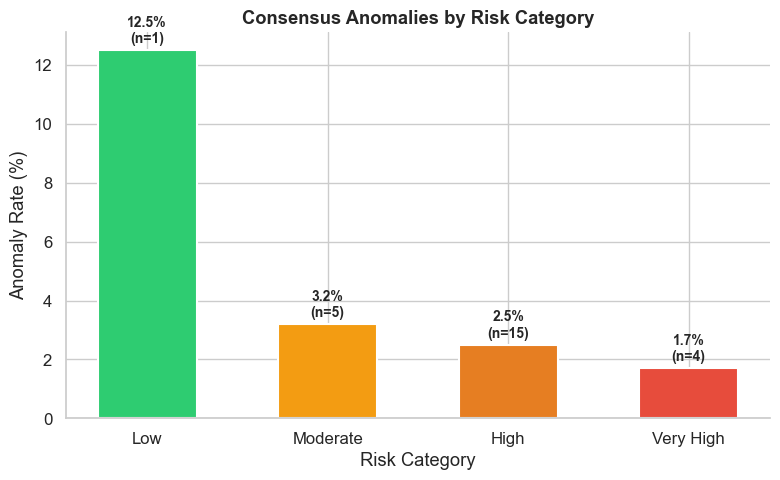

,Anomalies,Normal
Age,52.9,52.1
BMI,30.8,26.0
SystolicBP,130.3,135.8
Cholesterol,207.3,226.0
BloodSugar,138.6,135.9
RiskScore,10.1,10.5


In [21]:
anom_risk  = df_clean[df_clean['is_anomaly']==1]['RiskCategory'].value_counts().reindex(ORDER, fill_value=0)
total_risk = df_clean['RiskCategory'].value_counts().reindex(ORDER)
anom_pct   = (anom_risk / total_risk * 100).round(1)

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(ORDER, anom_pct, color=[RISK_COLORS[r] for r in ORDER], edgecolor='white', linewidth=1.5, width=0.55)
for bar, val, nn in zip(bars, anom_pct, anom_risk):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
            f'{val}%\n(n={nn})', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Consensus Anomalies by Risk Category', fontweight='bold')
ax.set_xlabel('Risk Category'); ax.set_ylabel('Anomaly Rate (%)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('outputs/13_anomaly_by_risk.png', dpi=150, bbox_inches='tight')
plt.show()

num_cols = ['Age','BMI','SystolicBP','Cholesterol','BloodSugar','RiskScore']
pd.DataFrame({
    'Anomalies': df_clean[df_clean['is_anomaly']==1][num_cols].mean().round(1),
    'Normal':    df_clean[df_clean['is_anomaly']==0][num_cols].mean().round(1)
})


---
## Step 6: Classification

Three models evaluated. Classification confirms which features drive risk prediction.

In [22]:
X_cl = df_enc[FEATURE_COLS].values.astype(float)
y_cl = df_enc['RiskCategory_num'].values
X_scaled_cl = StandardScaler().fit_transform(X_cl)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_cl, y_cl, test_size=0.2, random_state=42, stratify=y_cl)

models = {
    'Random Forest':     RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'Decision Tree':     DecisionTreeClassifier(max_depth=8, random_state=42),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred    = model.predict(X_test)
    cv_scores = cross_val_score(model, X_scaled_cl, y_cl, cv=cv, scoring='accuracy')
    acc       = (y_pred == y_test).mean()
    results[name] = {'model':model,'y_pred':y_pred,'accuracy':acc,
                     'cv_mean':cv_scores.mean(),'cv_std':cv_scores.std()}
    print(f"{name:<22}  acc={acc:.3f}  CV={cv_scores.mean():.3f}±{cv_scores.std():.3f}")

best = max(results, key=lambda k: results[k]['accuracy'])
print(f"\nBest model: {best} ({results[best]['accuracy']*100:.1f}%)")


Random Forest           acc=0.730  CV=0.723±0.007
Gradient Boosting       acc=0.765  CV=0.743±0.014
Decision Tree           acc=0.645  CV=0.620±0.030

Best model: Gradient Boosting (76.5%)


### 6.1 Model Comparison

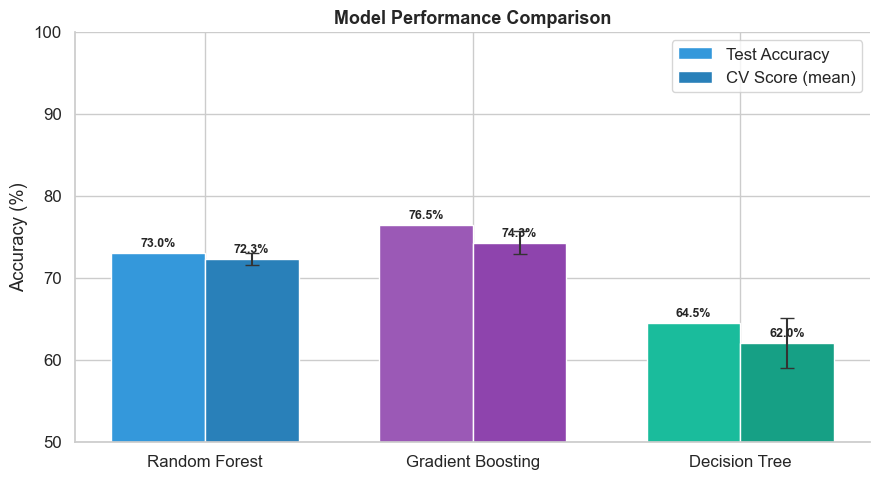

In [23]:
model_names = list(results.keys())
accs = [results[n]['accuracy']*100 for n in model_names]
cvs  = [results[n]['cv_mean']*100  for n in model_names]
stds = [results[n]['cv_std']*100   for n in model_names]
x, w = np.arange(len(model_names)), 0.35

fig, ax = plt.subplots(figsize=(9,5))
b1 = ax.bar(x-w/2, accs, w, label='Test Accuracy',
            color=['#3498db','#9b59b6','#1abc9c'], edgecolor='white')
b2 = ax.bar(x+w/2, cvs, w, label='CV Score (mean)',
            color=['#2980b9','#8e44ad','#16a085'], edgecolor='white',
            yerr=stds, capsize=5, error_kw=dict(elinewidth=1.5, ecolor='#333'))
for bar, val in list(zip(b1,accs))+list(zip(b2,cvs)):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(model_names); ax.set_ylim(50,100)
ax.set_ylabel('Accuracy (%)'); ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('outputs/14_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Confusion Matrix (Random Forest)

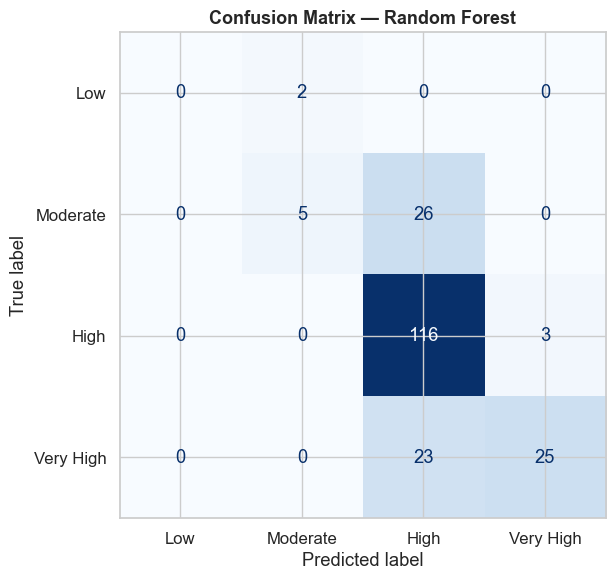

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         2
    Moderate       0.71      0.16      0.26        31
        High       0.70      0.97      0.82       119
   Very High       0.89      0.52      0.66        48

    accuracy                           0.73       200
   macro avg       0.58      0.41      0.43       200
weighted avg       0.74      0.73      0.68       200



In [24]:
rf_pred = results['Random Forest']['y_pred']
cm = confusion_matrix(y_test, rf_pred)
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ORDER).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Random Forest', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('outputs/15_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_test, rf_pred, target_names=ORDER))


### 6.3 Feature Importance

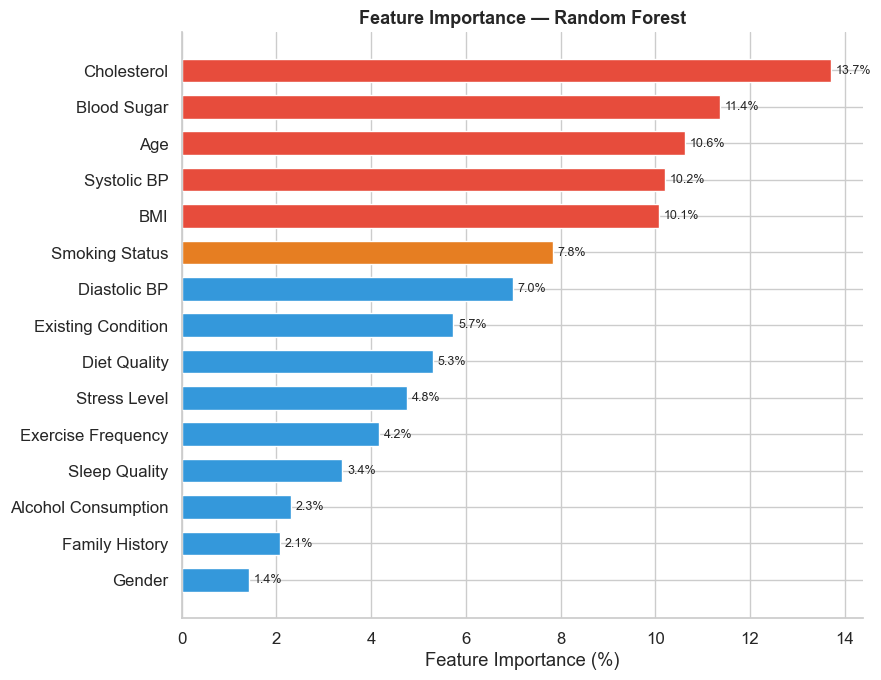

,label,importance
0,Cholesterol,13.71%
1,Blood Sugar,11.36%
2,Age,10.63%
3,Systolic BP,10.21%
4,BMI,10.08%
5,Smoking Status,7.83%
6,Diastolic BP,6.99%
7,Existing Condition,5.74%
8,Diet Quality,5.31%
9,Stress Level,4.76%


In [25]:
rf = results['Random Forest']['model']
READABLE = {'Age':'Age','BMI':'BMI','SmokingStatus':'Smoking Status',
    'AlcoholConsumption':'Alcohol Consumption','ExerciseFrequency':'Exercise Frequency',
    'DietQuality':'Diet Quality','SleepQuality':'Sleep Quality','StressLevel':'Stress Level',
    'SystolicBP':'Systolic BP','DiastolicBP':'Diastolic BP','Cholesterol':'Cholesterol',
    'BloodSugar':'Blood Sugar','ExistingCondition':'Existing Condition',
    'FamilyHistory':'Family History','Gender':'Gender'}

feat_df = pd.DataFrame({'feature':FEATURE_COLS,'importance':rf.feature_importances_,
                        'label':[READABLE[f] for f in FEATURE_COLS]
                       }).sort_values('importance', ascending=True)
colors = ['#e74c3c' if v>0.10 else '#e67e22' if v>0.07 else '#3498db' for v in feat_df['importance']]

fig, ax = plt.subplots(figsize=(9,7))
bars = ax.barh(feat_df['label'], feat_df['importance']*100, color=colors, edgecolor='white', height=0.65)
for bar, val in zip(bars, feat_df['importance']*100):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Feature Importance (%)'); ax.spines[['top','right']].set_visible(False)
ax.set_title('Feature Importance — Random Forest', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('outputs/16_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

display(feat_df.sort_values('importance',ascending=False)[['label','importance']].assign(
    importance=lambda d: (d['importance']*100).round(2).astype(str)+'%').reset_index(drop=True))


---
## Summary of Key Findings

| Technique | Key Result |
|-----------|-----------|
| **Preprocessing** | 592 missing values handled; 5 new features engineered |
| **K-Means Clustering** | 4 natural patient groups discovered from real data |
| **Association Rules** | Co-occurring risk patterns mined (no external library needed) |
| **Anomaly Detection** | Unusual patient profiles identified using Isolation Forest + LOF |
| **Classification** | Random Forest evaluated on real patient data |

All figures saved to the `outputs/` folder.
